#### PCA (주성분 분석)
- 차원 축소 기법
    - 피쳐의 개수가 줄어든다. 
- 고차원 데이터(다수의 피쳐를 가진 데이터셋)를 상관관계가 없는 새로운 축으로 변환 
- 데이터의 분산을 최대한 보존하면서 차원을 줄여서 시각화 
- parameter
    - n_components
        - 기본값 : None
        - 주성분의 개수 또는 비율로 설정 
        - None : 모든 주성분을 유지 
        - int : 선택할 주성분의 개수 
        - float(0~1) : 누적 설명 분산 비율을 기준으로 필요한 주성분의 개수를 선택 
        - 'mle' -> 자동으로 최적 차원 수 측정 (샘플의 개수 < 피려의 개수 인 경우메나 사용이 가능)
    - whiten
        - 기본값 : False
        - 주성분 벡터를 단위 분산으로 정규화를 할 것인가 지정 
        - 데이터의 정규화 효과
    - svd_solver
        - 기본값 :  'auto'
        - 분해 방식 지정 
        - 'auto' : 데이터의 크기에 따라서 자동 선택 
        - 'full' : 정확한 SVD 계산(적은 데이터에서 사용)
        - 'randomized' : 확률적 근사 알고리즘 ( 대규모 데이터에서 유용 )
- 속성
    - components_
        - 선택된 주성분 벡터 
    - explained_variance_
        - 각 주성분이 설명하는 분산 값
    - explained_vatiance_ratio_
        - 각 주성분이 설명하는 분산의 비율
        - 합계가 1에 가까울수록 원래 분산을 잘 보존 
    - singular_values_
        - 선택된 주성분에 대응하는 특이값
    - noise_variance_
        - 유지하지 않은 차원에서의 분산 추정치
- 메서드 
    - fit(X, y)
        - 주성분을 학습 
    - tansform(X)
        - 학습된 주성분 축을 기준으로 하여 새로운 데이터 변환
    - fit_transform(X, y)
        - PCA 학습 + 변환
    - get_covaiance()
        - PCA로 추정된 공분산 행렬 변환
    - get_precision()
        - PCA로 추정된 정밀도 행렬 변환

In [1]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, r2_score

In [2]:
# iris 데이터 로드 
iris = pd.read_csv("../csv/iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
x = iris.drop('species', axis=1)
y = iris['species']

In [4]:
# PCA 객체 생성 
pca = PCA()

In [5]:
X_pca = pca.fit_transform(x, y)

In [6]:
pd.concat( [ x, pd.DataFrame(X_pca) ], axis=1 )

,sepal_length,sepal_width,petal_length,petal_width,0,1,2,3
0,5.1,3.5,1.4,0.2,-2.684126,0.319397,-0.027915,0.002262
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001,-0.210464,0.099027
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949,0.017900,0.019968
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299,0.031559,-0.075576
4,5.0,3.6,1.4,0.2,-2.728717,0.326755,0.090079,-0.061259
...,...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.944110,0.187532,0.177825,0.426196
146,6.3,2.5,5.0,1.9,1.527167,-0.375317,-0.121898,0.254367
147,6.5,3.0,5.2,2.0,1.764346,0.078859,0.130482,0.137001
148,6.2,3.4,5.4,2.3,1.900942,0.116628,0.723252,0.044595


In [7]:
# 각 성분 별 분산의 비율을 출력 
ex_var_ratio = pca.explained_variance_ratio_

In [8]:
# 분산의 비율을 누적합 생성 
cum_var_ratio = np.cumsum(ex_var_ratio)
cum_var_ratio

array([0.92461872, 0.97768521, 0.99478782, 1.        ])

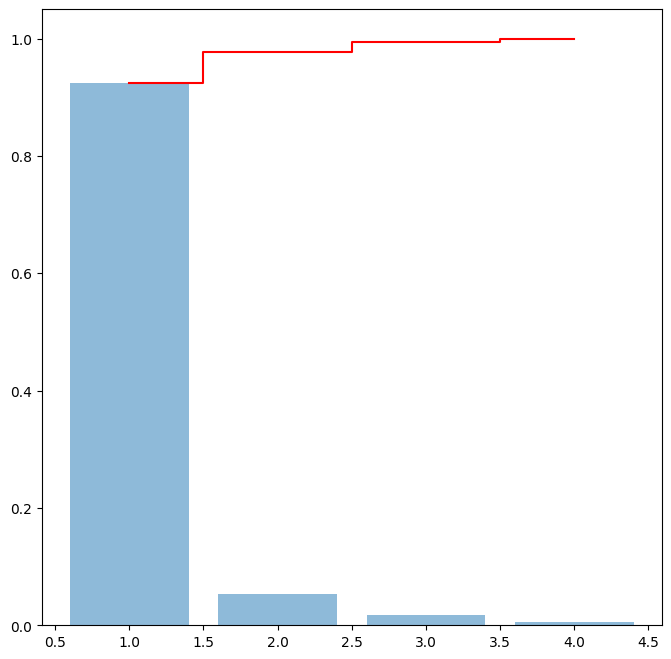

In [9]:
# 분산의 비율을 그래프 시각화
plt.figure(figsize = (8, 8))

plt.bar(
    range(1, len(ex_var_ratio) + 1), ex_var_ratio, alpha=0.5
)

plt.step(
    range(1, len(cum_var_ratio) + 1), cum_var_ratio, 
    color = 'red', where='mid'
)

plt.show()

- 막대 : 각 주성분이 설명하는 분산의 비율
- 선 : 누적 분산의 비율
- 일반적으로 누적 분산의 비율이 90% ~ 95%이상이 되는 지점까지의 주성분만 선택하는 경우가 다수 -> 차원 축소의 근거 


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# KFold 생성 
cv = StratifiedKFold(
    n_splits=5, shuffle=True, random_state=42
)

# Pipeline 생성 -> Scaler -> PCA -> SVC
pipe = Pipeline(
    [
        ('scaler', StandardScaler()), 
        ('pca', PCA(random_state=42)), 
        ('svc', SVC(random_state=42, probability=True))
    ]
)

# 최적의 파라미터를 찾기위한 파라미터의 조합 
params = {
    'pca__n_components' : [None, 2, 3], 
    "svc__C" : [0.1, 1, 10], 
    'svc__gamma' : ['scale', 'auto'], 
    'svc__kernel' : ['linear', 'rbf']
}

# GridSearchCV 객체를 생성
grid = GridSearchCV(
    estimator= pipe, 
    param_grid= params, 
    scoring= 'accuracy', 
    cv = cv, 
    n_jobs = 1, 
    verbose= 1, 
    refit = True
)

In [13]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'pca__n_components': [None, 2, ...], 'svc__C': [0.1, 1, ...], 'svc__gamma': ['scale', 'auto'], 'svc__kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [14]:
# 최적의 모델을 무엇인가? 최적의 파라미터는 무엇인가
print('Best estimator : ', grid.best_estimator_)
print('Best Parameter : ', grid.best_params_)
print(classification_report(
    y_test, grid.predict(X_test)
))

Best estimator :  Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(random_state=42)),
                ('svc',
                 SVC(C=0.1, kernel='linear', probability=True,
                     random_state=42))])
Best Parameter :  {'pca__n_components': None, 'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [15]:
pd.DataFrame(
    grid.cv_results_
).sort_values('mean_test_score', ascending=False)[ 
    ['mean_fit_time', 'params', 'mean_test_score']
]

,mean_fit_time,params,mean_test_score
0,0.006909,"{'pca__n_components': None, 'svc__C': 0.1, 'sv...",0.975000
2,0.005663,"{'pca__n_components': None, 'svc__C': 0.1, 'sv...",0.975000
6,0.000000,"{'pca__n_components': None, 'svc__C': 1, 'svc_...",0.975000
4,0.008395,"{'pca__n_components': None, 'svc__C': 1, 'svc_...",0.975000
24,0.004717,"{'pca__n_components': 3, 'svc__C': 0.1, 'svc__...",0.975000
26,0.003496,"{'pca__n_components': 3, 'svc__C': 0.1, 'svc__...",0.975000
28,0.006124,"{'pca__n_components': 3, 'svc__C': 1, 'svc__ga...",0.966667
29,0.005383,"{'pca__n_components': 3, 'svc__C': 1, 'svc__ga...",0.966667
8,0.006944,"{'pca__n_components': None, 'svc__C': 10, 'svc...",0.966667
9,0.008520,"{'pca__n_components': None, 'svc__C': 10, 'svc...",0.966667
